# total mensual de viajeros internacionales



In [200]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option("display.max_columns" , None)

In [201]:
archivo = Path( "Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx" )

if not archivo.exists(): raise FileNotFoundError(f"no está el archivo: {archivo.resolve()}" )
datos = pd.read_excel(archivo)

print("dataset:", datos.shape)
print(datos.columns.tolist())

datos.head()

dataset: (161036, 13)
['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región', 'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia', 'Tipo de Viajero', 'Viajero']


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


In [202]:
columnas_necesarias={
    "Año",
    "Mes cod",
    "Tipo de Viajero",
    "Viajero"
}

los_faltantes = columnas_necesarias - set( datos.columns)

if los_faltantes: raise KeyError( "Faltan estas columnas: " + ", ".join(sorted(los_faltantes)))

print("todas las columnas necesarias están.")

todas las columnas necesarias están.


In [203]:
datos["Año"] = pd.to_numeric( datos[ "Año"], errors ="coerce")
datos["Mes cod"] = pd.to_numeric(datos["Mes cod"], errors ="coerce")
datos["Viajero"] = pd.to_numeric( datos["Viajero"] , errors ="coerce")

datos["Fecha"] = pd.to_datetime(
    {"year": datos["Año"], "month": datos["Mes cod"], "day": 1},

    errors ="coerce"
)

print("fechas inválidas:", datos["Fecha"].isna().sum())
print("valores inválidos en Viajero:", datos["Viajero"].isna().sum())

print("fecha mínima:", datos["Fecha"].min())
print("fecha máxima:", datos["Fecha"].max())

fechas inválidas: 0
valores inválidos en Viajero: 0
fecha mínima: 2009-01-01 00:00:00
fecha máxima: 2026-06-01 00:00:00


In [204]:
datos["Tipo de Viajero"].value_counts(dropna=False)

Tipo de Viajero
Turista          117912
Viajero           23190
Excursionista     19730
Cruceristas         204
Name: count, dtype: int64

### Copia con filtro
en las notas del dataset dice que la categoría Viajero tuvo un cambio fuerte entre 2022 y 2023 por lo que no conviene incluirla en la serie comparable del período completo.

para construir esta serie solo están las categorías Turista y Excursionista, debido a que son comparables durante todo el período

In [205]:
tipos_seleccionados = ["Turista", "Excursionista"]

datos_visitantes = datos[datos["Tipo de Viajero"].isin(tipos_seleccionados)].copy()

datos["Tipo de Viajero"].isin(tipos_seleccionados)


0          True
1          True
2          True
3          True
4          True
          ...  
161031     True
161032    False
161033     True
161034    False
161035     True
Name: Tipo de Viajero, Length: 161036, dtype: bool

In [206]:
print("Filas originales:", len(datos))
print("Filas después del filtro:", len(datos_visitantes))

print("\nTipos de viajero incluidos:")
print(datos_visitantes["Tipo de Viajero"].value_counts())

Filas originales: 161036
Filas después del filtro: 137642

Tipos de viajero incluidos:
Tipo de Viajero
Turista          117912
Excursionista     19730
Name: count, dtype: int64


### construcción

In [207]:
serie_total = (
    datos_visitantes
    .dropna(subset=["Fecha", "Viajero"])
    .groupby("Fecha")["Viajero"]
    .sum()
    .sort_index()
    .asfreq("MS")
)

serie_total.name = "total_mensual"

print("inicio:", serie_total.index.min() )
print("fin:", serie_total.index.max() )
print("frecuencia:", serie_total.index.freqstr )
print("número de observaciones:" , len(serie_total ) )
print("meses faltantes:" , serie_total.isna().sum() )

serie_total.head()

inicio: 2009-01-01 00:00:00
fin: 2026-06-01 00:00:00
frecuencia: MS
número de observaciones: 210
meses faltantes: 0


Fecha
2009-01-01    149944.029345
2009-02-01    127303.692203
2009-03-01    158795.673819
2009-04-01    172013.467694
2009-05-01    124559.524351
Freq: MS, Name: total_mensual, dtype: float64

### Estadísticas

In [208]:
estadisticas = serie_total.describe()
estadisticas

count       210.000000
mean     222437.680412
std       84724.938827
min        9779.000000
25%      170714.476564
50%      227605.662595
75%      278341.208767
max      449114.070500
Name: total_mensual, dtype: float64

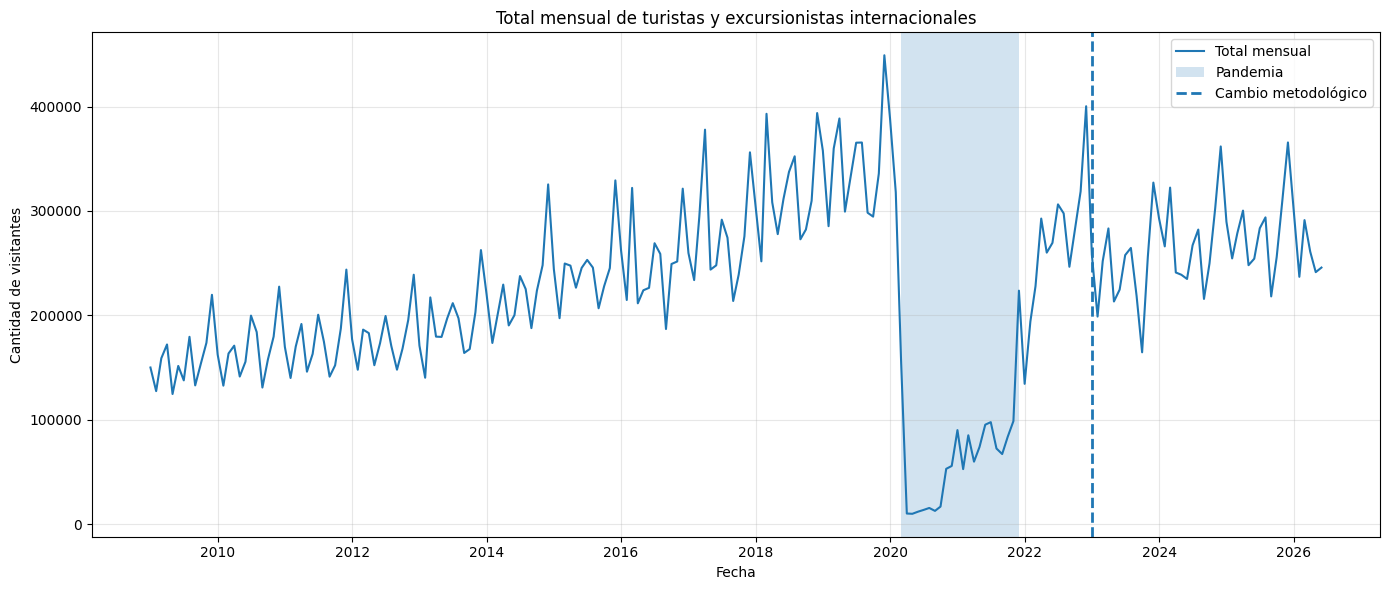

In [209]:
plt.figure(figsize= (14, 6) )

plt.plot(serie_total.index,serie_total,label="Total mensual")

plt.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-12-01"),
    alpha=0.2 , label= "Pandemia"
)

plt.axvline(
    pd.Timestamp("2023-01-01"),
    linestyle="--", linewidth = 2 ,
    label="Cambio metodológico"
)

plt.title("Total mensual de turistas y excursionistas internacionales")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de visitantes")
plt.legend()
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

### media móvil de 12 meses

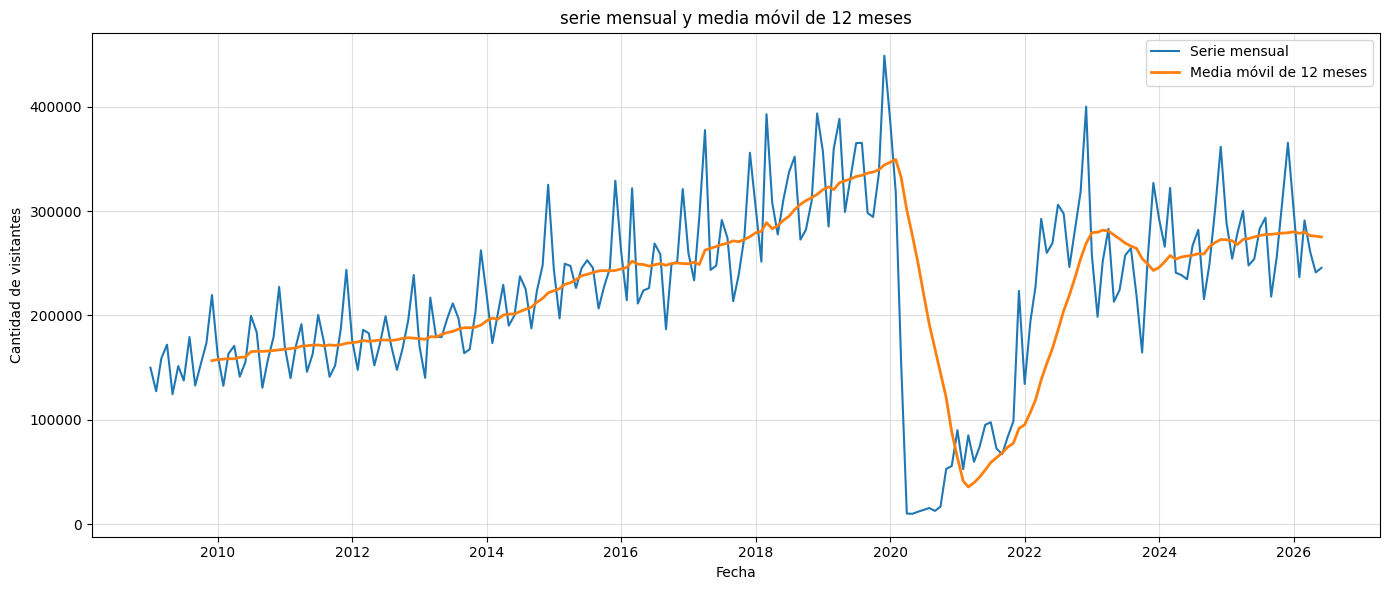

In [210]:
media_movil_12 = serie_total.rolling(12).mean()

plt.figure(figsize =( 14, 6))

plt.plot( serie_total.index,
    serie_total,
    label="Serie mensual"
)

plt.plot( media_movil_12.index,
    media_movil_12 ,
    linewidth = 2,
    label="Media móvil de 12 meses"
)

plt.title("serie mensual y media móvil de 12 meses" )
plt.xlabel("Fecha")
plt.ylabel( "Cantidad de visitantes")
plt.legend()
plt.grid(alpha = 0.4)
plt.tight_layout()
plt.show()